# Task 1
Потрібно проаналізувати взаємозв'язок між користувачами, сесіями та виручкою за днями. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.

* Сформуйте таблицю мінімум на 30 днів із колонками "date", "users", "sessions", "revenue".
* Розрахуйте кореляційну матрицю для цих метрик.
* Побудуйте діаграми розсіювання для пар: users-sessions, users-revenue, sessions-revenue.
* Побудуйте лінійний графік "revenue" за датами.
* Виведіть матрицю та всі графіки.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

             users  sessions   revenue
users     1.000000  0.994226  0.994226
sessions  0.994226  1.000000  1.000000
revenue   0.994226  1.000000  1.000000


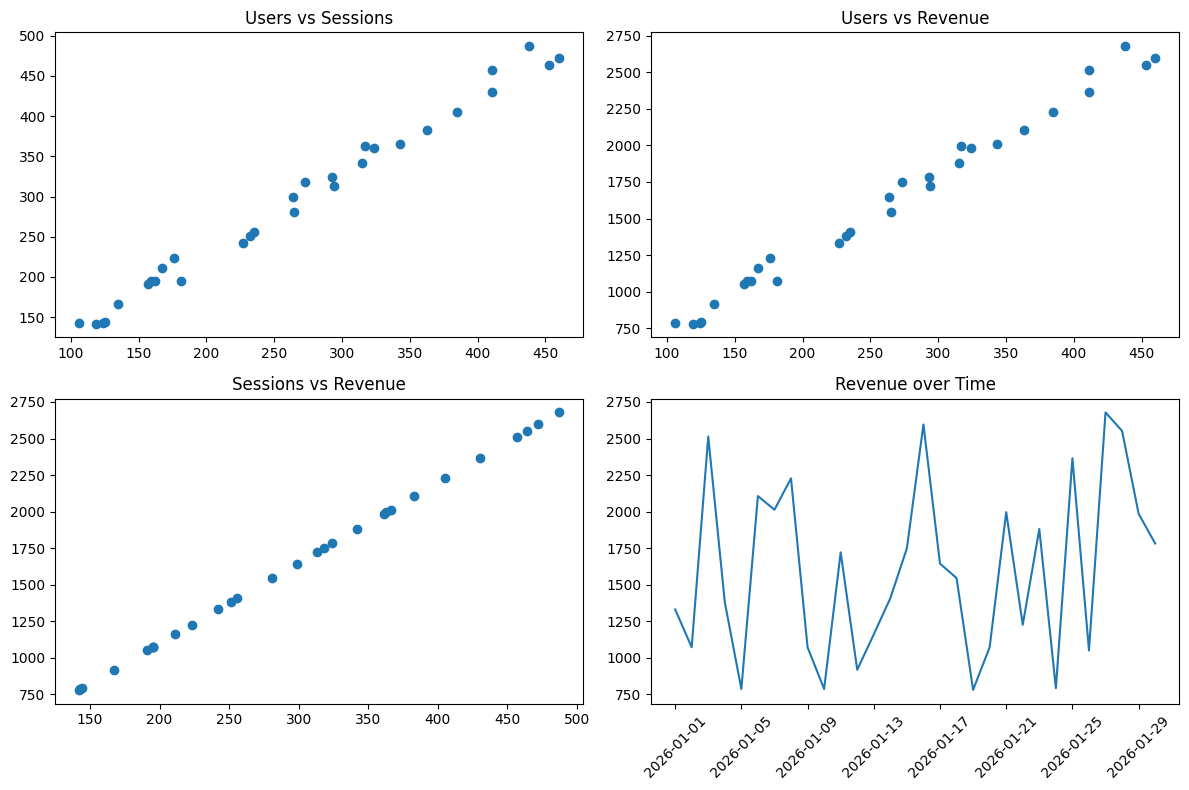

In [18]:
dates = pd.date_range(start='2026-01-01', periods=30)
users = np.random.randint(100, 500, 30)
sessions = users + np.random.randint(10, 50, 30)
revenue = sessions * 5.5

df = pd.DataFrame({'date': dates, 'users': users, 'sessions': sessions, 'revenue': revenue})

print(df[['users', 'sessions', 'revenue']].corr())

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].scatter(df['users'], df['sessions'])
axs[0, 0].set_title('Users vs Sessions')

axs[0, 1].scatter(df['users'], df['revenue'])
axs[0, 1].set_title('Users vs Revenue')

axs[1, 0].scatter(df['sessions'], df['revenue'])
axs[1, 0].set_title('Sessions vs Revenue')

axs[1, 1].plot(df['date'], df['revenue'])
axs[1, 1].set_title('Revenue over Time')
axs[1, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

# Task 2
Потрібно проаналізувати дані A/B-експерименту та візуалізувати конверсії. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.

* Сформуйте таблицю з полями "group" (A або B) і "converted" (0/1) з не менш ніж 100 спостереженнями в кожній групі.
* Розрахуйте конверсію в групах, абсолютну різницю та відносну зміну.
* Побудуйте 95% довірчі інтервали для конверсії в кожній групі.
* Побудуйте стовпчасту діаграму конверсій груп із відображенням довірчих інтервалів.
* Виведіть усі розраховані значення та графік.

In [10]:
from statsmodels.stats.proportion import proportion_confint
from matplotlib.ticker import PercentFormatter

Group A CR: 12.00%
Group B CR: 16.00%
Absolute Difference: 4.00%
Relative Change: 33.33%


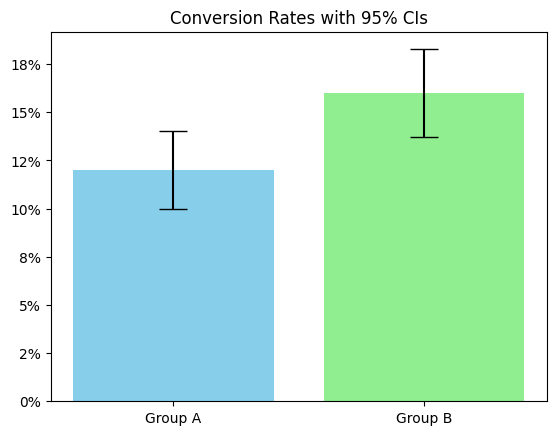

In [11]:
group_a = ['A'] * 1000
conv_a = [1] * 120 + [0] * 880

group_b = ['B'] * 1000
conv_b = [1] * 160 + [0] * 840

df = pd.DataFrame({'group': group_a + group_b, 'converted': conv_a + conv_b})

cr_a = df[df['group'] == 'A']['converted'].mean()
cr_b = df[df['group'] == 'B']['converted'].mean()

abs_diff = cr_b - cr_a
rel_change = (cr_b - cr_a) / cr_a

low_a, up_a = proportion_confint(sum(conv_a), len(conv_a), 0.05)
low_b, up_b = proportion_confint(sum(conv_b), len(conv_b), 0.05)
ci_a = up_a - cr_a
ci_b = up_b - cr_b

print(f"Group A CR: {cr_a:.2%}")
print(f"Group B CR: {cr_b:.2%}")
print(f"Absolute Difference: {abs_diff:.2%}")
print(f"Relative Change: {rel_change:.2%}")

fig, ax = plt.subplots()

ax.bar(['Group A', 'Group B'], [cr_a, cr_b], yerr=[ci_a, ci_b], capsize=10, color=['skyblue', 'lightgreen'])
ax.set_title('Conversion Rates with 95% CIs')
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

plt.show()

# Task 3
Потрібно перевірити дію центральної граничної теореми на прикладі несиметричного розподілу. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.

* Згенеруйте генеральну сукупність щонайменше з 50 000 спостережень із несиметричного розподілу.
* Сформуйте кілька підвибірок фіксованого розміру n і для кожної обчисліть середнє.
* Збережіть вибіркові середні та побудуйте їхню гістограму.
* Повторіть процедуру для щонайменше двох різних n і виведіть обидві гістограми.
* Виведіть середнє і стандартне відхилення вибіркових середніх для кожного n.

n=5: Mean = 1.71, Std = 0.43
n=50: Mean = 1.78, Std = 0.13


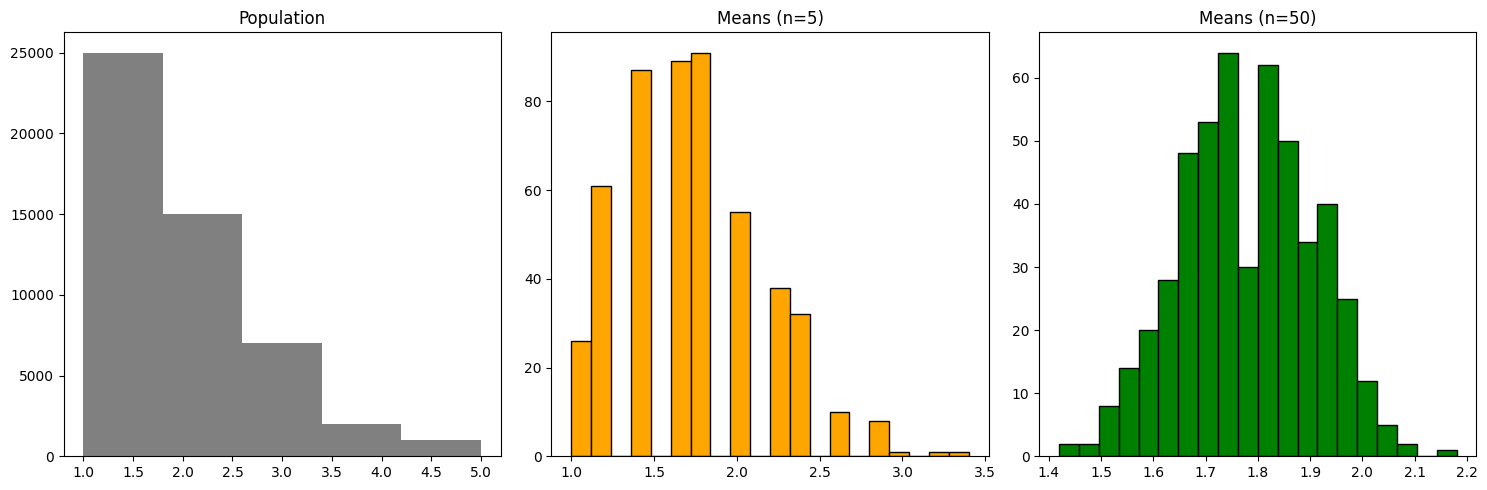

In [12]:
population = [1]*25000 + [2]*15000 + [3]*7000 + [4]*2000 + [5]*1000

def get_sample_means(pop, n, num_samples=500):
    return [np.mean(np.random.choice(pop, n)) for _ in range(num_samples)]

means_5 = get_sample_means(population, 5)
means_50 = get_sample_means(population, 50)

print(f"n=5: Mean = {np.mean(means_5):.2f}, Std = {np.std(means_5):.2f}")
print(f"n=50: Mean = {np.mean(means_50):.2f}, Std = {np.std(means_50):.2f}")

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].hist(population, bins=5, color='gray')
axs[0].set_title('Population')

axs[1].hist(means_5, bins=20, color='orange', edgecolor='black')
axs[1].set_title('Means (n=5)')

axs[2].hist(means_50, bins=20, color='green', edgecolor='black')
axs[2].set_title('Means (n=50)')

fig.tight_layout()
plt.show()

# Task 4
Потрібно проаналізувати часовий ряд продажів і візуалізувати ковзаючі метрики. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.

* Сформуйте таблицю "date" і "sales" за 90 днів.
* Додайте ковзне середнє і ковзне стандартне відхилення за обраним вікном.
* Побудуйте графік вихідних продажів і графік ковзного середнього на одному полі.
* Побудуйте окремий графік ковзного стандартного відхилення.
* Виведіть таблицю з першими рядками нових стовпців і обидва графіки.

        date  sales  rolling_mean  rolling_std
0 2024-02-04    206           NaN          NaN
1 2024-02-05    576           NaN          NaN
2 2024-02-06    264           NaN          NaN
3 2024-02-07    456           NaN          NaN
4 2024-02-08    335           NaN          NaN
5 2024-02-09    504           NaN          NaN
6 2024-02-10    577    416.857143   149.791442
7 2024-02-11    549    465.857143   123.030387
8 2024-02-12    309    427.714286   124.570882
9 2024-02-13    545    467.857143   107.067624


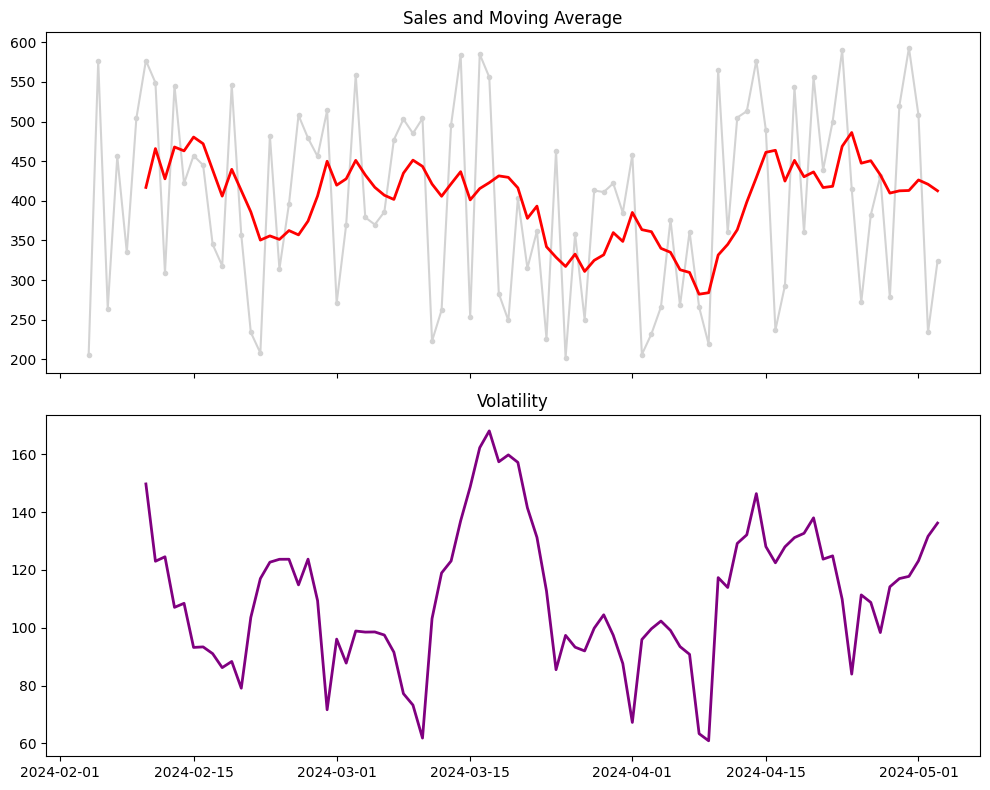

In [17]:
dates = pd.date_range(start='2024-02-04', periods=90)
sales = np.random.randint(200, 600, 90)

df = pd.DataFrame({'date': dates, 'sales': sales})

df['rolling_mean'] = df['sales'].rolling(window=7).mean()
df['rolling_std'] = df['sales'].rolling(window=7).std()

print(df.head(10))

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(df['date'], df['sales'], color='lightgray', marker='.')
axs[0].plot(df['date'], df['rolling_mean'], color='red', linewidth=2)
axs[0].set_title('Sales and Moving Average')

axs[1].plot(df['date'], df['rolling_std'], color='purple', linewidth=2)
axs[1].set_title('Volatility')

fig.tight_layout()
plt.show()